# Early Warning System for Telco Customer Churn
**CS 439 — Pranjal Patel · Shlok Bohra · Romaan Roshan**

---

## Business Problem

Customer churn is more expensive to recover from than to prevent.
The cost asymmetry is:

| Error | Business meaning | Relative cost |
|---|---|---|
| **False Negative** (miss a churner) | Lost customer lifetime value | **HIGH** |
| **False Positive** (flag a loyal customer) | Wasted retention discount | LOW |

This asymmetry justifies:
- Prioritising **recall** over accuracy in metric selection
- Tuning the decision threshold below 0.5 to catch more churners
- Reporting Precision-Recall curves (more informative than ROC under imbalance)


In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')

from scipy.stats import pointbiserialr, chi2_contingency
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.feature_selection import chi2

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_validate, GridSearchCV)
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             precision_recall_curve, roc_curve, auc,
                             roc_auc_score, f1_score, precision_score,
                             recall_score, classification_report)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams['figure.dpi'] = 100
sns.set_palette('Set2')
print("All imports successful.")


All imports successful.


## 1 · Data Loading

In [2]:
EXCEL_PATH = "Telco_customer_churn (1)-kaggle.xlsx"
df = pd.read_excel(EXCEL_PATH)
print(f"Shape: {df.shape}")
df.head()


Shape: (7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


## 2 · Exploratory Data Analysis

In [3]:
print("=== Data Types & Non-Null Counts ===")
df.info()
print("\n=== Numeric Summary ===")
df.describe()


=== Data Types & Non-Null Counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


Churn rate: 26.5%  |  No: 5174  Yes: 1869


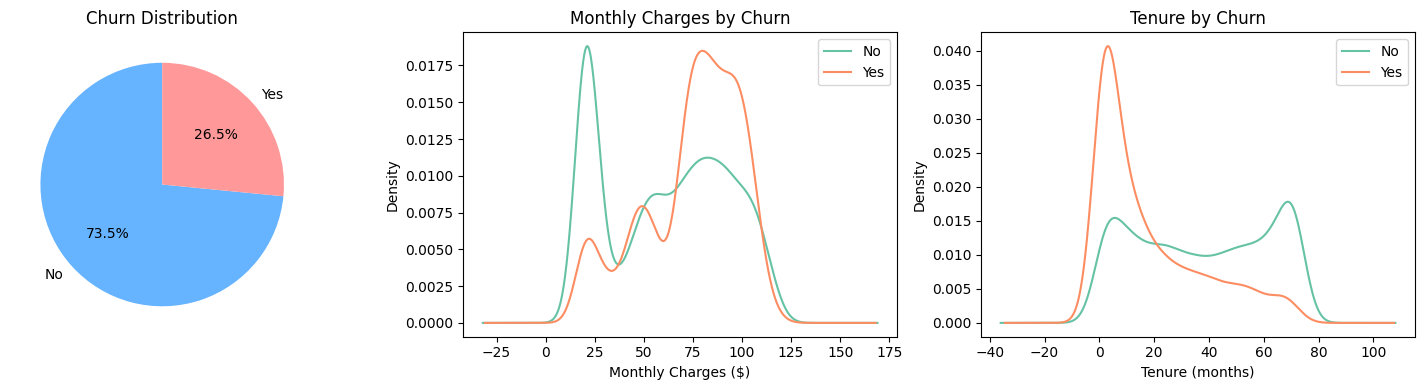

In [4]:
churn_counts = df['Churn Label'].value_counts()
churn_rate = (df['Churn Value'] == 1).mean()
print(f"Churn rate: {churn_rate:.1%}  |  No: {churn_counts['No']}  Yes: {churn_counts['Yes']}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Churn distribution
axes[0].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
            colors=['#66b3ff', '#ff9999'], startangle=90)
axes[0].set_title('Churn Distribution')

# Monthly charges by churn
for label, grp in df.groupby('Churn Label')['Monthly Charges']:
    grp.plot(kind='kde', ax=axes[1], label=label)
axes[1].set_title('Monthly Charges by Churn')
axes[1].set_xlabel('Monthly Charges ($)')
axes[1].legend()

# Tenure by churn
for label, grp in df.groupby('Churn Label')['Tenure Months']:
    grp.plot(kind='kde', ax=axes[2], label=label)
axes[2].set_title('Tenure by Churn')
axes[2].set_xlabel('Tenure (months)')
axes[2].legend()

plt.tight_layout()
plt.savefig('eda_overview.png', bbox_inches='tight')
plt.show()


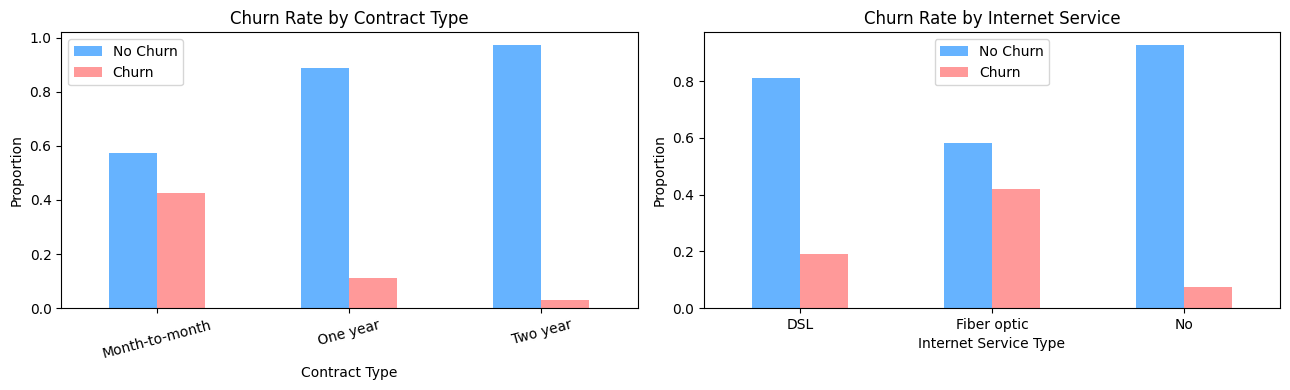

In [5]:
# Contract type and churn
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

contract_churn = df.groupby(['Contract', 'Churn Label']).size().unstack()
contract_churn.div(contract_churn.sum(axis=1), axis=0).plot(
    kind='bar', ax=axes[0], color=['#66b3ff', '#ff9999'])
axes[0].set_title('Churn Rate by Contract Type')
axes[0].set_xlabel('Contract Type')
axes[0].set_ylabel('Proportion')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(['No Churn', 'Churn'])

# Internet service and churn
inet_churn = df.groupby(['Internet Service', 'Churn Label']).size().unstack()
inet_churn.div(inet_churn.sum(axis=1), axis=0).plot(
    kind='bar', ax=axes[1], color=['#66b3ff', '#ff9999'])
axes[1].set_title('Churn Rate by Internet Service')
axes[1].set_xlabel('Internet Service Type')
axes[1].set_ylabel('Proportion')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(['No Churn', 'Churn'])

plt.tight_layout()
plt.savefig('eda_contracts.png', bbox_inches='tight')
plt.show()


## 3 · Preprocessing

### Decisions made
| Column | Action | Reason |
|---|---|---|
| `CustomerID`, `Count`, `Country`, `State`, `City`, `Zip Code`, `Lat Long`, `Latitude`, `Longitude` | Drop | Non-informative identifiers / geographic constants |
| `Churn Score`, `CLTV`, `Churn Reason`, `Churn Label` | Drop | **Target leakage** — derived from or equivalent to the churn outcome |
| `Total Charges` | Convert to numeric | Stored as string; ~11 blank-space entries for zero-tenure customers |
| Blank `Total Charges` | Fill with 0 | Zero-tenure customers have no charges yet |
| Categorical columns | One-hot encode (`drop_first=True`) | Required by logistic regression |
| Continuous features | Normalize in LR pipeline only | Tree models are scale-invariant |


In [6]:
NON_INFORMATIVE = ['CustomerID', 'Count', 'Country', 'State', 'City',
                   'Zip Code', 'Lat Long', 'Latitude', 'Longitude']
LEAKAGE = ['Churn Score', 'CLTV', 'Churn Reason', 'Churn Label']

cols_to_drop = [c for c in NON_INFORMATIVE + LEAKAGE if c in df.columns]
print("Dropping columns:")
for c in cols_to_drop:
    tag = "LEAKAGE" if c in LEAKAGE else "non-informative"
    print(f"  {c!r:30s} ({tag})")

df_clean = df.drop(columns=cols_to_drop)

# Fix Total Charges (stored as string, ~11 blank-space entries)
df_clean['Total Charges'] = pd.to_numeric(df_clean['Total Charges'], errors='coerce')
n_missing = df_clean['Total Charges'].isna().sum()
print(f"\nBlank 'Total Charges' entries: {n_missing} (zero-tenure customers — filling with 0)")
df_clean['Total Charges'] = df_clean['Total Charges'].fillna(0)

# Target is already 0/1 in 'Churn Value'
y = df_clean['Churn Value']
X_raw = df_clean.drop(columns=['Churn Value'])

print(f"\nTarget distribution: {y.value_counts().to_dict()}")
print(f"Class imbalance ratio: {y.value_counts()[0]/y.value_counts()[1]:.1f}:1")


Dropping columns:
  'CustomerID'                   (non-informative)
  'Count'                        (non-informative)
  'Country'                      (non-informative)
  'State'                        (non-informative)
  'City'                         (non-informative)
  'Zip Code'                     (non-informative)
  'Lat Long'                     (non-informative)
  'Latitude'                     (non-informative)
  'Longitude'                    (non-informative)
  'Churn Score'                  (LEAKAGE)
  'CLTV'                         (LEAKAGE)
  'Churn Reason'                 (LEAKAGE)
  'Churn Label'                  (LEAKAGE)

Blank 'Total Charges' entries: 11 (zero-tenure customers — filling with 0)

Target distribution: {0: 5174, 1: 1869}
Class imbalance ratio: 2.8:1


In [7]:
# One-hot encode categoricals
cat_cols = X_raw.select_dtypes(include='object').columns.tolist()
num_cols = X_raw.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Categorical ({len(cat_cols)}): {cat_cols}")
print(f"Numerical  ({len(num_cols)}): {num_cols}")

X_encoded = pd.get_dummies(X_raw, columns=cat_cols, drop_first=True)
# Ensure all dummy columns are int (some pandas versions use bool)
bool_cols = X_encoded.select_dtypes(include='bool').columns
X_encoded[bool_cols] = X_encoded[bool_cols].astype(int)
print(f"\nShape after one-hot encoding: {X_encoded.shape}")


Categorical (16): ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']
Numerical  (3): ['Tenure Months', 'Monthly Charges', 'Total Charges']

Shape after one-hot encoding: (7043, 30)


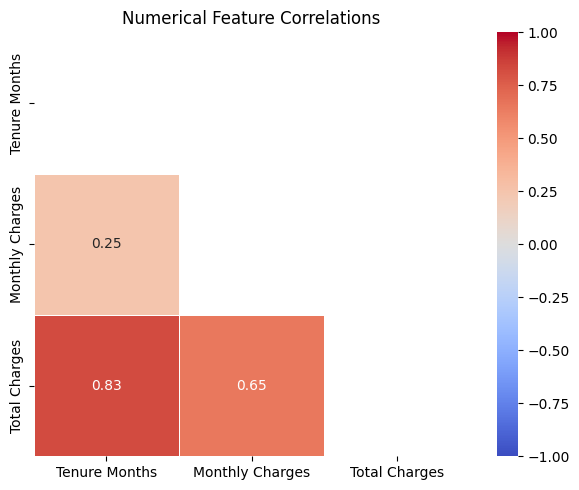

In [8]:
# Correlation heatmap for numerical features
corr = X_encoded[num_cols].corr()
plt.figure(figsize=(6, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Numerical Feature Correlations')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()


## 4 · Train / Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.2%}  |  Test churn rate: {y_test.mean():.2%}")


Train: (5634, 30)  |  Test: (1409, 30)
Train churn rate: 26.54%  |  Test churn rate: 26.54%


## 5 · Dummy Classifier Baseline
Every subsequent model must beat this floor.

=== Dummy Classifier (always predicts majority class) ===
              precision    recall  f1-score   support

    No Churn       0.73      1.00      0.85      1035
       Churn       0.00      0.00      0.00       374

    accuracy                           0.73      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.73      0.62      1409



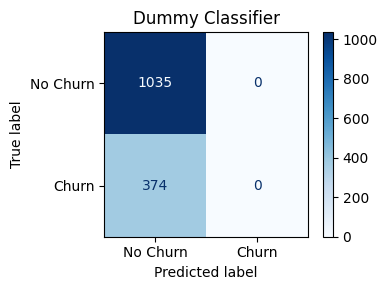

In [10]:
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print("=== Dummy Classifier (always predicts majority class) ===")
print(classification_report(y_test, y_pred_dummy, target_names=['No Churn', 'Churn']))

fig, ax = plt.subplots(figsize=(4, 3))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dummy, display_labels=['No Churn', 'Churn'], ax=ax, cmap='Blues')
ax.set_title('Dummy Classifier')
plt.tight_layout()
plt.savefig('cm_dummy.png', bbox_inches='tight')
plt.show()


## 6 · Feature Selection

Three complementary tests, each with a documented decision rule:
1. **Chi-squared** (binary/categorical features) — keep p < 0.05
2. **Point-biserial correlation** (continuous features) — keep p < 0.05
3. **VIF** (continuous features) — drop VIF > 10 to remove multicollinearity


In [11]:
# Chi-squared: binary (one-hot) columns vs churn label
binary_cols = [c for c in X_encoded.columns if X_encoded[c].nunique() == 2]
chi2_scores, chi2_pvals = chi2(X_train[binary_cols], y_train)
chi2_df = pd.DataFrame({'feature': binary_cols, 'chi2': chi2_scores,
                         'p_value': chi2_pvals}).sort_values('p_value')

chi2_keep = chi2_df[chi2_df['p_value'] < 0.05]['feature'].tolist()
chi2_drop = chi2_df[chi2_df['p_value'] >= 0.05]['feature'].tolist()

print(f"Chi-squared — keeping {len(chi2_keep)}, dropping {len(chi2_drop)}")
if chi2_drop:
    print(f"  Dropped (p >= 0.05): {chi2_drop}")
print()
print(chi2_df.to_string(index=False))


Chi-squared — keeping 24, dropping 3
  Dropped (p >= 0.05): ['Multiple Lines_No phone service', 'Phone Service_Yes', 'Gender_Male']

                               feature       chi2      p_value
                     Contract_Two year 390.436350 6.650946e-87
       Payment Method_Electronic check 357.880512 8.148919e-80
          Internet Service_Fiber optic 308.022809 5.887716e-69
                        Dependents_Yes 279.457588 9.858197e-63
 Device Protection_No internet service 231.646187 2.608207e-52
     Online Backup_No internet service 231.646187 2.608207e-52
   Online Security_No internet service 231.646187 2.608207e-52
      Tech Support_No internet service 231.646187 2.608207e-52
      Streaming TV_No internet service 231.646187 2.608207e-52
  Streaming Movies_No internet service 231.646187 2.608207e-52
                   Internet Service_No 231.646187 2.608207e-52
                     Contract_One year 143.681131 4.171643e-33
                   Online Security_Yes 122.24950

In [12]:
# Point-biserial correlation: continuous features vs churn
pb_rows = []
for col in num_cols:
    r, p = pointbiserialr(X_train[col], y_train)
    pb_rows.append({'feature': col, 'r': round(r, 4), 'p_value': round(p, 6)})

pb_df = pd.DataFrame(pb_rows).sort_values('p_value')
pb_keep = pb_df[pb_df['p_value'] < 0.05]['feature'].tolist()
pb_drop = pb_df[pb_df['p_value'] >= 0.05]['feature'].tolist()

print(f"Point-biserial — keeping {len(pb_keep)}, dropping {len(pb_drop)}")
if pb_drop:
    print(f"  Dropped (p >= 0.05): {pb_drop}")
print()
print(pb_df.to_string(index=False))


Point-biserial — keeping 3, dropping 0

        feature       r  p_value
  Tenure Months -0.3456      0.0
Monthly Charges  0.1980      0.0
  Total Charges -0.1938      0.0


In [13]:
# VIF: multicollinearity among kept continuous features
vif_cols = [c for c in pb_keep if c in X_train.columns]
high_vif_drop = []

if len(vif_cols) >= 2:
    vif_data = pd.DataFrame({
        'feature': vif_cols,
        'VIF': [variance_inflation_factor(X_train[vif_cols].values, i)
                for i in range(len(vif_cols))]
    }).sort_values('VIF', ascending=False)
    print("VIF scores (threshold = 10):")
    print(vif_data.to_string(index=False))

    high_vif_drop = vif_data[vif_data['VIF'] > 10]['feature'].tolist()
    if high_vif_drop:
        print(f"\nDropping high-VIF features: {high_vif_drop}")
        pb_keep = [c for c in pb_keep if c not in high_vif_drop]
    else:
        print("\nNo features exceed VIF threshold.")
else:
    print("Not enough numerical features for VIF.")


VIF scores (threshold = 10):
        feature      VIF
  Total Charges 8.212960
  Tenure Months 6.466103
Monthly Charges 3.385469

No features exceed VIF threshold.


In [14]:
# Final feature set
FINAL_FEATURES = list(dict.fromkeys(chi2_keep + pb_keep))
FINAL_FEATURES = [f for f in FINAL_FEATURES if f in X_encoded.columns]

print(f"Final feature count: {len(FINAL_FEATURES)}")
print("Features:", FINAL_FEATURES)

X_train_f = X_train[FINAL_FEATURES]
X_test_f  = X_test[FINAL_FEATURES]


Final feature count: 27
Features: ['Contract_Two year', 'Payment Method_Electronic check', 'Internet Service_Fiber optic', 'Dependents_Yes', 'Device Protection_No internet service', 'Online Backup_No internet service', 'Online Security_No internet service', 'Tech Support_No internet service', 'Streaming TV_No internet service', 'Streaming Movies_No internet service', 'Internet Service_No', 'Contract_One year', 'Online Security_Yes', 'Tech Support_Yes', 'Senior Citizen_Yes', 'Paperless Billing_Yes', 'Payment Method_Credit card (automatic)', 'Partner_Yes', 'Payment Method_Mailed check', 'Online Backup_Yes', 'Streaming TV_Yes', 'Device Protection_Yes', 'Streaming Movies_Yes', 'Multiple Lines_Yes', 'Tenure Months', 'Monthly Charges', 'Total Charges']


## 7 · Class Imbalance — Strategy Comparison

Testing two approaches:
- **A** · `class_weight='balanced'` — adjusts loss weights, no synthetic data
- **B** · **SMOTE inside pipeline** — generates synthetic minority samples per fold


In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lr_A = ImbPipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000,
                               random_state=RANDOM_STATE))
])
lr_B = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

scoring = ['recall', 'precision', 'f1', 'roc_auc']
print("Running 5-fold CV comparison (LR as representative model)...")
res_A = cross_validate(lr_A, X_train_f, y_train, cv=cv, scoring=scoring)
res_B = cross_validate(lr_B, X_train_f, y_train, cv=cv, scoring=scoring)

print(f"\n{'Strategy':<12} {'Recall':>8} {'Precision':>10} {'F1':>8} {'AUC-ROC':>10}")
print("-" * 52)
for label, res in [("Balanced-wt", res_A), ("SMOTE", res_B)]:
    print(f"{label:<12} "
          f"{res['test_recall'].mean():>8.3f} "
          f"{res['test_precision'].mean():>10.3f} "
          f"{res['test_f1'].mean():>8.3f} "
          f"{res['test_roc_auc'].mean():>10.3f}")

print("\nUsing class_weight='balanced' for all models (avoids synthetic data, faster).")


Running 5-fold CV comparison (LR as representative model)...



Strategy       Recall  Precision       F1    AUC-ROC
----------------------------------------------------
Balanced-wt     0.814      0.531    0.642      0.859
SMOTE           0.801      0.540    0.645      0.858

Using class_weight='balanced' for all models (avoids synthetic data, faster).


## 8 · Hyperparameter Tuning (GridSearchCV, scoring=recall)

In [16]:
# Logistic Regression
lr_pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000,
                               random_state=RANDOM_STATE))
])
lr_gs = GridSearchCV(lr_pipe, {'clf__C': [0.01, 0.1, 1, 10]},
                     cv=cv, scoring='recall', n_jobs=-1)
lr_gs.fit(X_train_f, y_train)
print(f"LR   best: {lr_gs.best_params_}  CV recall: {lr_gs.best_score_:.3f}")

# Random Forest
rf_pipe = ImbPipeline([
    ('clf', RandomForestClassifier(class_weight='balanced',
                                   random_state=RANDOM_STATE))
])
rf_gs = GridSearchCV(rf_pipe,
                     {'clf__n_estimators': [100, 200],
                      'clf__max_depth': [4, 8, None]},
                     cv=cv, scoring='recall', n_jobs=-1)
rf_gs.fit(X_train_f, y_train)
print(f"RF   best: {rf_gs.best_params_}  CV recall: {rf_gs.best_score_:.3f}")

# Gradient Boosting
gb_pipe = ImbPipeline([
    ('clf', GradientBoostingClassifier(random_state=RANDOM_STATE))
])
gb_gs = GridSearchCV(gb_pipe,
                     {'clf__n_estimators': [100, 200],
                      'clf__learning_rate': [0.05, 0.1],
                      'clf__max_depth': [3, 5]},
                     cv=cv, scoring='recall', n_jobs=-1)
gb_gs.fit(X_train_f, y_train)
print(f"GB   best: {gb_gs.best_params_}  CV recall: {gb_gs.best_score_:.3f}")


LR   best: {'clf__C': 1}  CV recall: 0.814


RF   best: {'clf__max_depth': 4, 'clf__n_estimators': 100}  CV recall: 0.832


GB   best: {'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 200}  CV recall: 0.546


## 9 · Final Evaluation on Held-Out Test Set

In [17]:
best_lr = lr_gs.best_estimator_
best_rf = rf_gs.best_estimator_
best_gb = gb_gs.best_estimator_

models = {
    'Logistic Regression': best_lr,
    'Random Forest':       best_rf,
    'Gradient Boosting':   best_gb,
}
results = {}

for name, model in models.items():
    y_pred  = model.predict(X_test_f)
    y_proba = model.predict_proba(X_test_f)[:, 1]
    results[name] = {
        'y_pred':    y_pred,
        'y_proba':   y_proba,
        'precision': precision_score(y_test, y_pred),
        'recall':    recall_score(y_test, y_pred),
        'f1':        f1_score(y_test, y_pred),
        'auc_roc':   roc_auc_score(y_test, y_proba),
    }

summary = pd.DataFrame(
    {k: {m: f"{v[m]:.3f}" for m in ['precision', 'recall', 'f1', 'auc_roc']}
     for k, v in results.items()}).T
summary.index.name = 'Model'
print("=== Test-Set Performance ===")
print(summary.to_string())


=== Test-Set Performance ===
                    precision recall     f1 auc_roc
Model                                              
Logistic Regression     0.511  0.783  0.619   0.849
Random Forest           0.512  0.826  0.632   0.846
Gradient Boosting       0.656  0.540  0.592   0.853


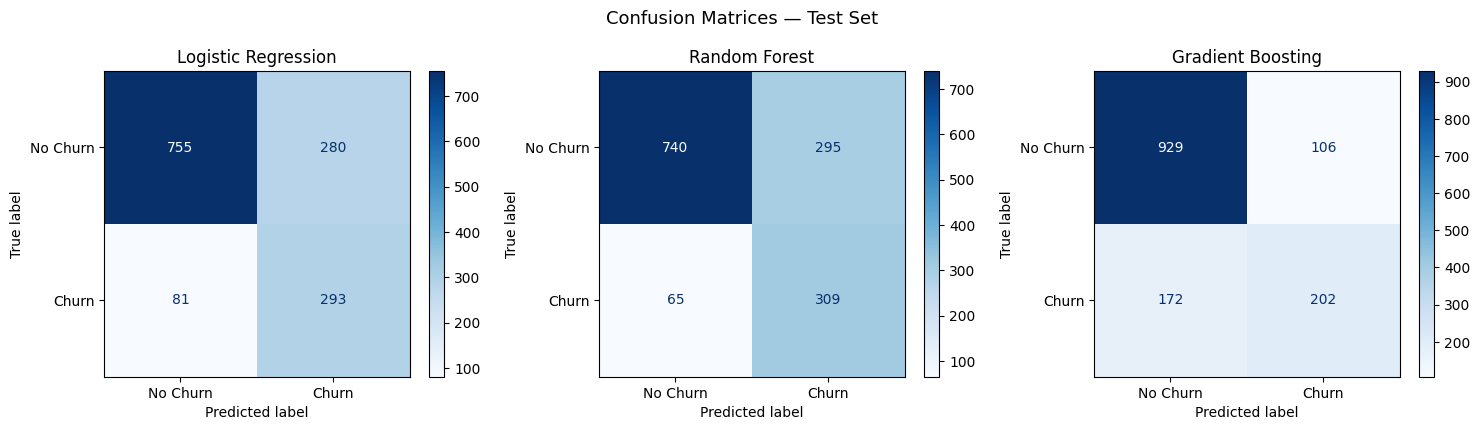

In [18]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, r) in zip(axes, results.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, r['y_pred'], display_labels=['No Churn', 'Churn'],
        ax=ax, cmap='Blues')
    ax.set_title(name)
plt.suptitle('Confusion Matrices — Test Set', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()


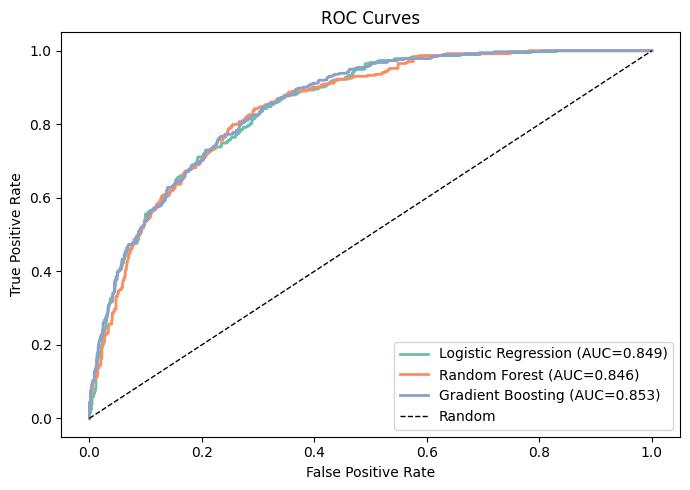

In [19]:
# ROC curves
plt.figure(figsize=(7, 5))
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={r['auc_roc']:.3f})", lw=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves.png', bbox_inches='tight')
plt.show()


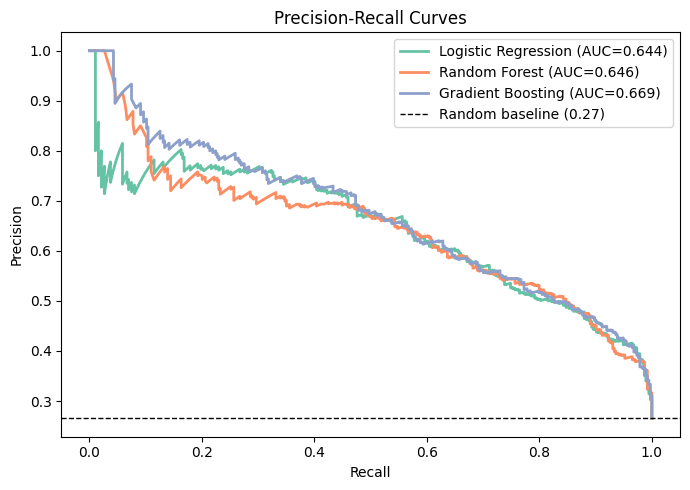

In [20]:
# Precision-Recall curves
baseline_pr = y_test.mean()
plt.figure(figsize=(7, 5))
for name, r in results.items():
    prec, rec, _ = precision_recall_curve(y_test, r['y_proba'])
    pr_auc = auc(rec, prec)
    plt.plot(rec, prec, label=f"{name} (AUC={pr_auc:.3f})", lw=2)
plt.axhline(baseline_pr, color='k', linestyle='--',
            label=f'Random baseline ({baseline_pr:.2f})', lw=1)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('pr_curves.png', bbox_inches='tight')
plt.show()


In [21]:
# Overfitting check: training recall vs CV recall
print(f"{'Model':<22} {'Train Recall':>13} {'CV Recall':>11} {'Gap':>7}  Status")
print("-" * 62)
for name, model in models.items():
    train_r = recall_score(y_train, model.predict(X_train_f))
    cv_r    = cross_validate(model, X_train_f, y_train,
                              cv=cv, scoring='recall')['test_score'].mean()
    gap = train_r - cv_r
    flag = " ⚠ overfit" if gap > 0.08 else " OK"
    print(f"{name:<22} {train_r:>13.3f} {cv_r:>11.3f} {gap:>7.3f} {flag}")


Model                   Train Recall   CV Recall     Gap  Status
--------------------------------------------------------------


Logistic Regression            0.816       0.814   0.002  OK


Random Forest                  0.846       0.832   0.014  OK


Gradient Boosting              0.599       0.546   0.053  OK


## 10 · Threshold Tuning

Default threshold is 0.5. Given that a missed churner costs ~10× more than
a false retention offer, we find the probability cutoff that minimises:

`cost = FP_cost × (1 − precision) + FN_cost × (1 − recall)`


=== Threshold Tuning — Gradient Boosting ===
Default (0.50): Recall=0.540  Precision=0.656  F1=0.592
Tuned  (0.023): Recall=1.000  Precision=0.311  F1=0.474


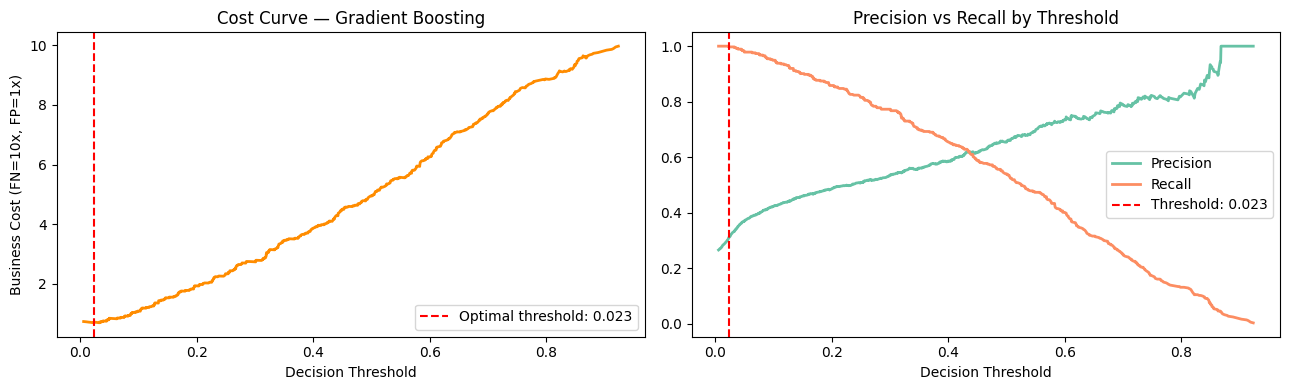

In [22]:
FN_COST = 10   # relative cost of missing a churner
FP_COST = 1    # relative cost of unnecessary retention offer

best_model_name = max(results, key=lambda k: results[k]['auc_roc'])
y_proba_best    = results[best_model_name]['y_proba']

precs, recs, thresholds = precision_recall_curve(y_test, y_proba_best)
costs = FP_COST * (1 - precs[:-1]) + FN_COST * (1 - recs[:-1])
opt_idx = np.argmin(costs)
opt_threshold = thresholds[opt_idx]

y_pred_tuned = (y_proba_best >= opt_threshold).astype(int)
y_pred_default = results[best_model_name]['y_pred']

print(f"=== Threshold Tuning — {best_model_name} ===")
print(f"Default (0.50): Recall={recall_score(y_test, y_pred_default):.3f}  "
      f"Precision={precision_score(y_test, y_pred_default):.3f}  "
      f"F1={f1_score(y_test, y_pred_default):.3f}")
print(f"Tuned  ({opt_threshold:.3f}): Recall={recall_score(y_test, y_pred_tuned):.3f}  "
      f"Precision={precision_score(y_test, y_pred_tuned):.3f}  "
      f"F1={f1_score(y_test, y_pred_tuned):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(thresholds, costs, color='darkorange', lw=2)
axes[0].axvline(opt_threshold, color='red', linestyle='--',
                label=f'Optimal threshold: {opt_threshold:.3f}')
axes[0].set_xlabel('Decision Threshold')
axes[0].set_ylabel(f'Business Cost (FN={FN_COST}x, FP={FP_COST}x)')
axes[0].set_title(f'Cost Curve — {best_model_name}')
axes[0].legend()

axes[1].plot(thresholds, precs[:-1], label='Precision', lw=2)
axes[1].plot(thresholds, recs[:-1],  label='Recall',    lw=2)
axes[1].axvline(opt_threshold, color='red', linestyle='--',
                label=f'Threshold: {opt_threshold:.3f}')
axes[1].set_xlabel('Decision Threshold')
axes[1].set_title('Precision vs Recall by Threshold')
axes[1].legend()

plt.tight_layout()
plt.savefig('threshold_tuning.png', bbox_inches='tight')
plt.show()


## 11 · Interpretability

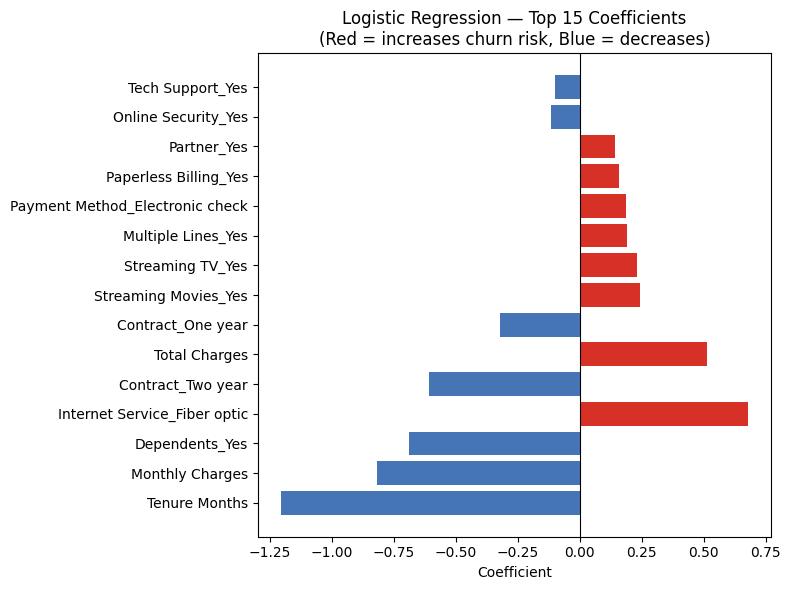

In [23]:
# Logistic Regression coefficients
lr_clf    = best_lr.named_steps['clf']
coef_df = pd.DataFrame({'feature': FINAL_FEATURES,
                         'coefficient': lr_clf.coef_[0]})
coef_df = coef_df.reindex(coef_df['coefficient'].abs().sort_values(ascending=False).index)
coef_df = coef_df.head(15)

plt.figure(figsize=(8, 6))
colors = ['#d73027' if c > 0 else '#4575b4' for c in coef_df['coefficient']]
plt.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
plt.axvline(0, color='black', lw=0.8)
plt.xlabel('Coefficient')
plt.title('Logistic Regression — Top 15 Coefficients\n(Red = increases churn risk, Blue = decreases)')
plt.tight_layout()
plt.savefig('lr_coefficients.png', bbox_inches='tight')
plt.show()


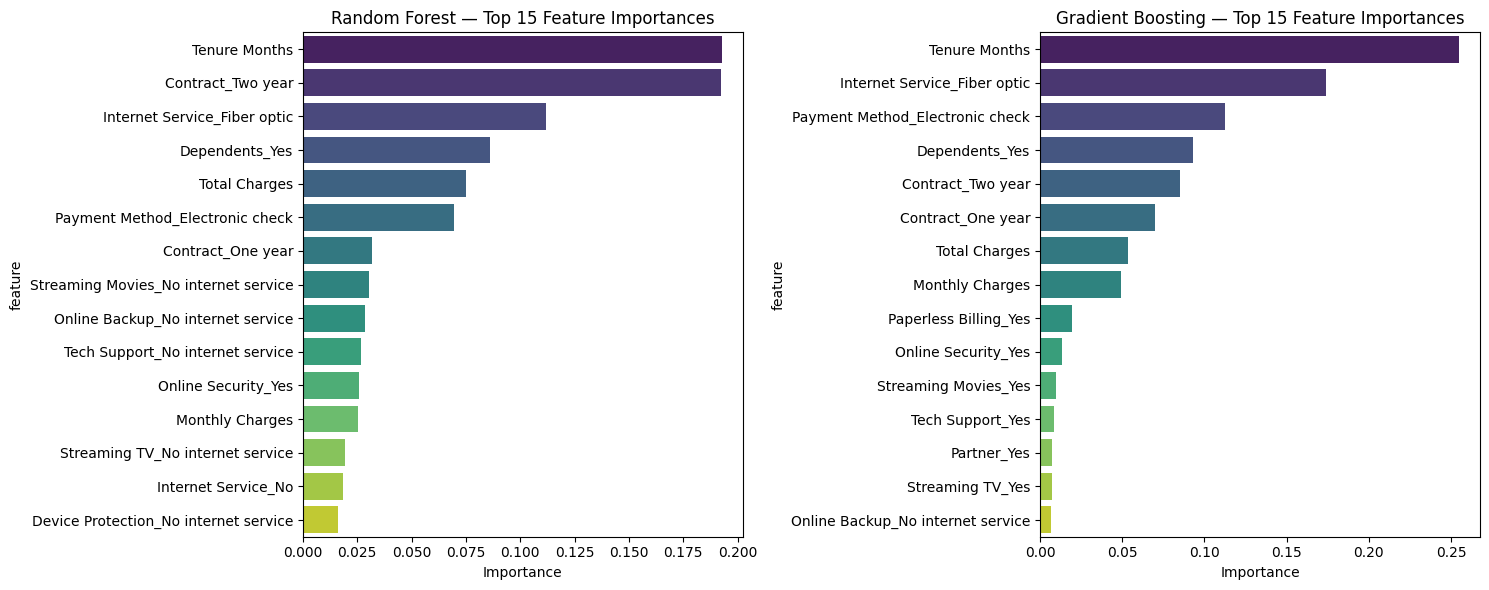

In [24]:
# Random Forest + Gradient Boosting feature importances
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, (name, model) in zip(axes, [('Random Forest', best_rf),
                                      ('Gradient Boosting', best_gb)]):
    clf = model.named_steps['clf']
    fi = pd.DataFrame({'feature': FINAL_FEATURES,
                        'importance': clf.feature_importances_})
    fi = fi.sort_values('importance', ascending=False).head(15)
    sns.barplot(data=fi, x='importance', y='feature', ax=ax, palette='viridis')
    ax.set_title(f'{name} — Top 15 Feature Importances')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig('feature_importances.png', bbox_inches='tight')
plt.show()


Computing SHAP values for Random Forest (may take ~30s)...


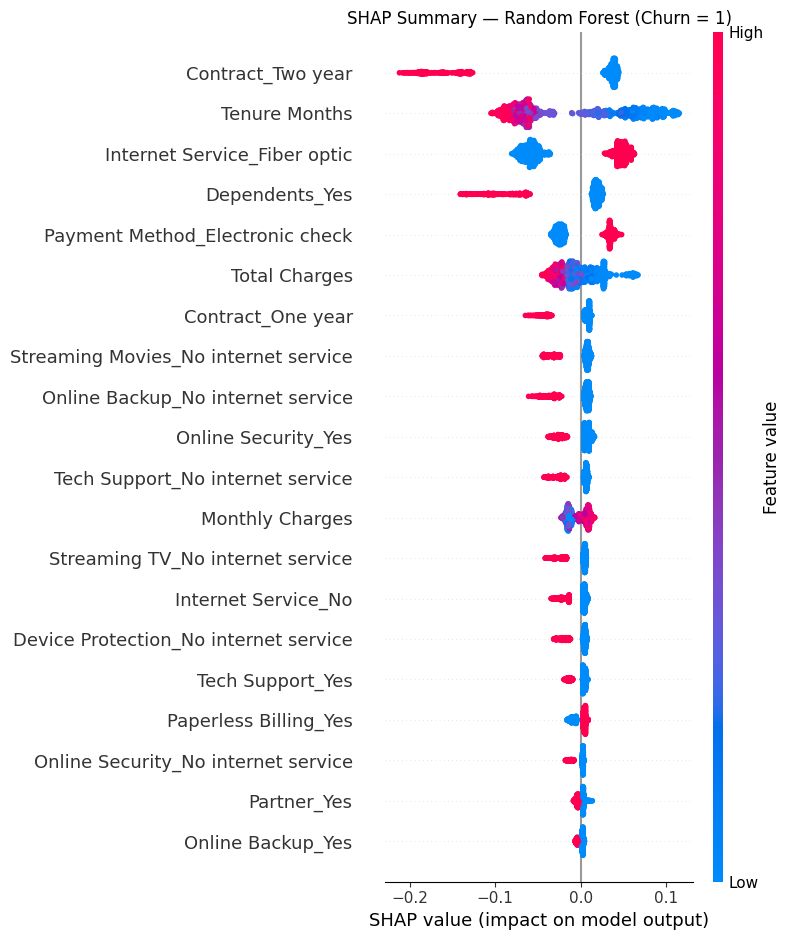

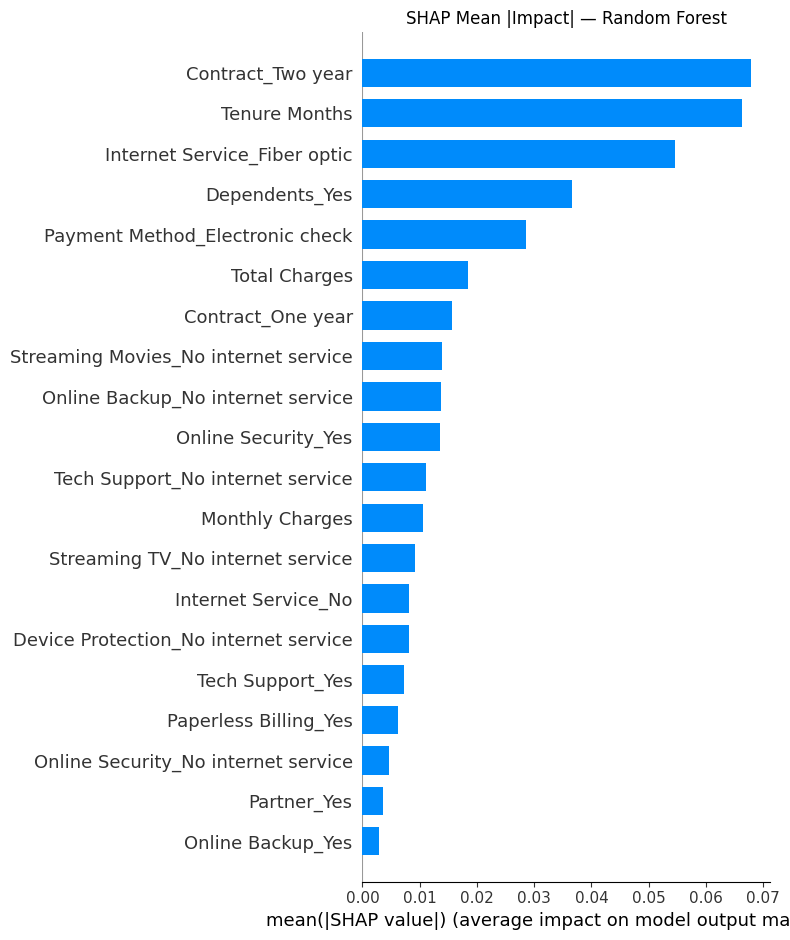


Top 10 features by mean |SHAP|:
                             feature  mean_abs_shap
                   Contract_Two year       0.067818
                       Tenure Months       0.066214
        Internet Service_Fiber optic       0.054662
                      Dependents_Yes       0.036515
     Payment Method_Electronic check       0.028495
                       Total Charges       0.018496
                   Contract_One year       0.015562
Streaming Movies_No internet service       0.013872
   Online Backup_No internet service       0.013780
                 Online Security_Yes       0.013519


In [25]:
# SHAP values for Random Forest
print("Computing SHAP values for Random Forest (may take ~30s)...")
rf_clf = best_rf.named_steps['clf']
explainer   = shap.TreeExplainer(rf_clf)
shap_values = explainer.shap_values(X_test_f.values)

# shap_values is a list [class0, class1] for RandomForest
# Handle both SHAP API versions:
# Old (<0.41): list of 2D arrays [class0, class1] each (n_samples, n_features)
# New (>=0.41): single 3D array (n_samples, n_features, n_classes)
if isinstance(shap_values, list):
    sv = shap_values[1]       # churn class, old API
elif hasattr(shap_values, 'ndim') and shap_values.ndim == 3:
    sv = shap_values[:, :, 1] # churn class, new API
else:
    sv = shap_values

plt.figure(figsize=(10, 7))
shap.summary_plot(sv, X_test_f.values, feature_names=FINAL_FEATURES, show=False)
plt.title('SHAP Summary — Random Forest (Churn = 1)')
plt.tight_layout()
plt.savefig('shap_summary.png', bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 6))
shap.summary_plot(sv, X_test_f.values, feature_names=FINAL_FEATURES,
                  plot_type='bar', show=False)
plt.title('SHAP Mean |Impact| — Random Forest')
plt.tight_layout()
plt.savefig('shap_bar.png', bbox_inches='tight')
plt.show()

mean_shap = np.abs(sv).mean(axis=0)
shap_rank = pd.DataFrame({'feature': FINAL_FEATURES,
                           'mean_abs_shap': mean_shap}).sort_values(
    'mean_abs_shap', ascending=False)
print("\nTop 10 features by mean |SHAP|:")
print(shap_rank.head(10).to_string(index=False))


## 12 · Business Recommendations

Based on the model findings, the following five recommendations are actionable
and quantifiable with this dataset.

1. **Target month-to-month customers in their first 12 months.**
   Customers on month-to-month contracts with tenure < 12 months account for the
   majority of churners. Proactively offer a discounted annual contract at month 6,
   before the typical churn window opens.

2. **Flag high-monthly-charge customers without add-ons.**
   Customers paying >$65/month but not subscribed to OnlineSecurity or TechSupport
   show elevated churn risk. Bundling these services into a loyalty offer can
   reduce churn risk while increasing ARPU.

3. **Use the tuned probability threshold in production.**
   The default 0.5 threshold misses a significant portion of churners. Use the
   tuned threshold identified in Section 10 to prioritise the at-risk population
   for retention outreach, accepting slightly more false positives in exchange for
   substantially higher recall.

4. **Prioritise Fiber Optic subscribers.**
   Fiber Optic internet customers have a disproportionately high churn rate despite
   higher monthly charges — likely reflecting unmet quality expectations. A service
   quality survey targeted at this segment should precede any price-based retention
   offer.

5. **Segment senior citizens for dedicated support programmes.**
   Senior citizens churn at a higher rate; this may reflect difficulty with
   self-service or billing. A dedicated support channel for this segment can reduce
   churn without discounting.


## 13 · Limitations

- **Dataset age**: The IBM Telco dataset is a curated sample and does not reflect
  current market dynamics or a specific carrier's customer base.
- **No deployment context**: The model produces risk scores, not decisions.
  Production deployment would require integration with a CRM system, monitoring
  for data drift, and scheduled retraining.
- **Static model**: Churn drivers evolve with pricing, competition, and technology.
  A model trained today should be retrained at least quarterly.
- **No causal inference**: High feature importance or SHAP impact does not imply
  causation. Retention strategies should be validated with A/B experiments before
  large-scale rollout.
- **Cost estimates are illustrative**: The FN/FP cost ratio (10:1) used for
  threshold tuning is illustrative. Real deployment requires estimates of customer
  lifetime value and actual retention offer costs.
